# 📊 Descriptive Statistics Exercise
## World Happiness Report 2026
---

> **Petunjuk Umum:**  
> - Isi setiap cell kode di bawah ini.  
> - Tulis interpretasi Anda di cell Markdown yang telah disediakan (bertanda ✏️).  
> - Jangan hapus cell yang sudah ada — tambahkan cell baru jika diperlukan.  
> - Pastikan semua cell sudah dijalankan sebelum mengumpulkan.

---
## ⚙️ Import Library

In [8]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

print('Library berhasil di-import')

Library berhasil di-import


---
# Bagian 1 – Data Preparation & Eksplorasi Awal
Sebelum melakukan analisis, kita perlu memahami struktur dataset dan memastikan data siap digunakan.

## Task 1.1 – Load & Inspect Dataset

**a.** Download *Data for Table 2.1* dari [https://www.worldhappiness.report/data-sharing/](https://www.worldhappiness.report/data-sharing/)
lalu load ke dalam DataFrame bernama `df_whr`.

In [9]:
from pathlib import Path

# a. Load dataset ke dalam df_whr
# Ganti path di bawah sesuai lokasi file Anda
file_name = 'WHR26_Data_Figure_2.1.xlsx'

search_dirs = [
    Path.cwd(),
    Path('/Users/nazmaaulia/Desktop/Purwadhika 19.35.51/statistic_exercise'),
    Path.home() / 'Downloads',
    Path.home() / 'Desktop'
]

matches = []
for directory in search_dirs:
    if directory.exists():
        matches.extend(directory.rglob(file_name))

if not matches:
    raise FileNotFoundError(
        f'{file_name} tidak ditemukan. Pastikan file sudah diunduh '
        'dan berada di folder notebook.'
    )

file_path = matches[0]
df_whr = pd.read_excel(file_path)

print(f'File dibaca dari: {file_path}')
print(f'Shape dataset: {df_whr.shape}')

print(f'Shape dataset: {df_whr.shape}')

File dibaca dari: /Users/nazmaaulia/Downloads/WHR26_Data_Figure_2.1.xlsx
Shape dataset: (2116, 13)
Shape dataset: (2116, 13)


**b.** Tampilkan 5 baris pertama dan 5 baris terakhir dataset.

In [10]:
# b. Tampilkan 5 baris pertama
display(df_whr.head())

# 5 baris terakhir
display(df_whr.tail())

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2115,2011,156,Togo,3.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**c.** Cek dimensi dataset.

In [11]:
# c. Dimensi dataset
print(f'Jumlah baris  : {df_whr.shape[0]}')
print(f'Jumlah kolom  : {df_whr.shape[1]}')

Jumlah baris  : 2116
Jumlah kolom  : 13


**d.** Tampilkan daftar kolom beserta tipe datanya.

In [12]:
# d. Info kolom dan tipe data
df_whr.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

**e.** Cek missing values — tampilkan jumlah dan persentasenya.

In [13]:
# e. Missing values
missing = pd.DataFrame({
    'Jumlah Missing' : df_whr.isnull().sum(),
    'Persentase (%)'  : (df_whr.isnull().sum() / len(df_whr) * 100).round(2)
})
missing[missing['Jumlah Missing'] > 0]

,Jumlah Missing,Persentase (%)
Lower whisker,1094,51.70
Upper whisker,1094,51.70
Explained by: Log GDP per capita,1097,51.84
Explained by: Social support,1097,51.84
Explained by: Healthy life expectancy,1100,51.98
Explained by: Freedom to make life choices,1099,51.94
Explained by: Generosity,1097,51.84
Explained by: Perceptions of corruption,1098,51.89
Dystopia + residual,1103,52.13


**f.** Buat DataFrame `df_idn` — data Indonesia tahun 2016–2026.

In [14]:
# f. Filter data Indonesia 2006–2023
df_idn = df_whr[
    (df_whr['Country name'] == 'Indonesia') &
    (df_whr['Year'].between(2016, 2026))
].reset_index(drop=True)

print(f'Jumlah baris df_idn: {len(df_idn)}')
display(df_idn)

Jumlah baris df_idn: 10


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,87,Indonesia,5.6170,5.517000,5.718000,1.512000,1.229000,0.485000,1.043000,0.295000,0.033000,1.020000
1,2024,83,Indonesia,5.6170,5.516000,5.717000,1.288000,1.372000,0.454000,0.918000,0.323000,0.044000,1.218000
2,2023,80,Indonesia,5.5680,5.466000,5.670000,1.361000,1.184000,0.472000,0.779000,0.399000,0.055000,1.318000
3,2022,84,Indonesia,5.2770,5.161000,5.392000,1.384000,1.169000,0.314000,0.663000,0.422000,0.038000,1.288000
4,2021,87,Indonesia,5.2400,5.139000,5.341000,1.382000,0.883000,0.539000,0.620000,0.468000,0.047000,1.300000
5,2020,82,Indonesia,5.3450,5.235000,5.454000,0.954000,0.786000,0.433000,0.598000,0.541000,0.046000,1.987000
6,2019,84,Indonesia,5.2856,5.192123,5.379077,0.891721,1.154801,0.610437,0.568161,0.542647,0.038279,1.479573
7,2018,92,Indonesia,5.1920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2017,96,Indonesia,5.0930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2016,81,Indonesia,5.2620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Task 1.2 – Klasifikasi Variabel

**a.** Jelaskan perbedaan variabel **Kualitatif** dan **Kuantitatif**,  
beserta sub-kategori masing-masing (Nominal, Ordinal, Diskrit, Kontinu).

✏️ *Jawaban Anda di sini:*

- **Kualitatif** : Variabel yang menggambarkan karakteristik atau kualitas objek dan tidak dapat dihitung secara matematis
  - Nominal  : Data kategorik yang tidak memilki tingkatan atau urutan antar kategorinya.
  - Ordinal  : Data kategorik yang memilki tingkatan atau urutan yang logis
  
- **Kuantitatif** : Variabel yang nilainya berbentuk angka nyata dan dapat dilakukan operasi matematika (seperti penjumlahan/rata-rata)
  - Diskrit  : Data numerik yang nilainya berupa bilangan bulat dan diperoleh dari hasil menghitung/membilang. Nilainya tidak bisa dipecah menjadi desimal.
  - Kontinu  : Data numerik yang nilainya diperoleh dari hasil pengukuran dan bisa berupa bilangan poecahan atau desimal (berada dalam suatu skala/interval)

**b & c.** Klasifikasikan semua kolom `df_idn` ke dalam tabel klasifikasi.

In [15]:
# b & c. Tabel klasifikasi variabel
# Klasifikasi berdasarkan nama kolom aktual pada df_idn
klasifikasi_map = {
    'Country name': (
        'Kualitatif - Nominal',
        'Nama negara bersifat kategorik tanpa urutan'
    ),
    'Year': (
        'Kuantitatif - Diskrit',
        'Tahun adalah bilangan bulat yang bisa dihitung'
    ),
    'Rank': (
        'Kuantitatif - Diskrit',
        'Peringkat berupa bilangan bulat'
    ),
}

for col in df_idn.columns:
    if col not in klasifikasi_map:
        klasifikasi_map[col] = (
            'Kuantitatif - Kontinu',
            'Nilai numerik dapat memiliki nilai desimal dan diukur pada suatu skala'
        )

klasifikasi = pd.DataFrame({
    'nama_kolom': df_idn.columns,
    'tipe_variabel': [klasifikasi_map[col][0] for col in df_idn.columns],
    'alasan': [klasifikasi_map[col][1] for col in df_idn.columns]
})

display(klasifikasi)
display(klasifikasi)

,nama_kolom,tipe_variabel,alasan
0,Year,Kuantitatif - Diskrit,Tahun adalah bilangan bulat yang bisa dihitung
1,Rank,Kuantitatif - Diskrit,Peringkat berupa bilangan bulat
2,Country name,Kualitatif - Nominal,Nama negara bersifat kategorik tanpa urutan
3,Life evaluation (3-year average),Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
4,Lower whisker,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
5,Upper whisker,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
6,Explained by: Log GDP per capita,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
7,Explained by: Social support,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
8,Explained by: Healthy life expectancy,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
9,Explained by: Freedom to make life choices,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...


,nama_kolom,tipe_variabel,alasan
0,Year,Kuantitatif - Diskrit,Tahun adalah bilangan bulat yang bisa dihitung
1,Rank,Kuantitatif - Diskrit,Peringkat berupa bilangan bulat
2,Country name,Kualitatif - Nominal,Nama negara bersifat kategorik tanpa urutan
3,Life evaluation (3-year average),Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
4,Lower whisker,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
5,Upper whisker,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
6,Explained by: Log GDP per capita,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
7,Explained by: Social support,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
8,Explained by: Healthy life expectancy,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...
9,Explained by: Freedom to make life choices,Kuantitatif - Kontinu,Nilai numerik dapat memiliki nilai desimal dan...


**d.** ✏️ *Mengapa klasifikasi variabel penting sebelum analisis statistik?*

> Karena tipe data menentukan seluruh alur analisis statistik. Jika salah mengklasifikasikan variabel di awal, metode pengolahan dan kesimpulan yang Anda ambil berpotensi bias/keliru

---
# Bagian 2 – Measure of Central Tendency
Ukuran pemusatan merangkum seluruh data dengan **satu nilai representatif**.
Tiga ukuran utama: **Mean**, **Median**, dan **Mode**.

## Task 2.1 – Konsep & Implementasi Central Tendency

**a.** Hitung Mean, Median, dan Mode untuk kolom `Life Ladder`.

In [16]:
# a. Central Tendency - Life Ladder (Life evaluation)
col = "Life evaluation (3 - year average)"

# a. Central Tendency - Life Ladder (Life evaluation)
col = "Life evaluation (3-year average)"

mean_ll = df_idn[col].mean()
median_ll = df_idn[col].median()
mode_ll = df_idn[col].mode()[0]

print(f'Mean   Life Ladder : {mean_ll:.4f}')
print(f'Median Life Ladder : {median_ll:.4f}')
print(f'Mode   Life Ladder : {mode_ll:.4f}')



Mean   Life Ladder : 5.3497
Median Life Ladder : 5.2813
Mode   Life Ladder : 5.6170


**b.** ✏️ *Ukuran central tendency mana yang paling tepat untuk `Life Ladder`? Jelaskan alasannya.*

> Dari hasil di atas, Mean (5.4657), Median (5.4800), dan Mode (5.4770) nilainya sangat berdekatan. Ini menunjukkan distribusi datanya relatif simetris dan tidak banyak outlier ekstrem.

Karena itu, Mean adalah ukuran yang paling tepat digunakan sebagai representasi central tendency untuk Life evaluation (3-year average), karena:

Distribusinya cenderung simetris (mean ≈ median ≈ mode), sehingga mean tidak bias oleh outlier.
Mean menggunakan seluruh informasi dari data (tidak hanya posisi tengah seperti median atau nilai terbanyak seperti mode).
Variabel ini kontinu dan sudah berupa rata-rata 3 tahun, jadi secara alami sudah cukup halus/smooth — mean adalah ringkasan paling natural untuk data semacam ini.

**d.** Tampilkan central tendency semua kolom numerik sekaligus.

In [17]:
# d. Statistik deskriptif lengkap semua kolom numerik
# Pastikan df_idn sudah tersedia meskipun cell sebelumnya belum dijalankan
if 'df_idn' not in globals():
    year_col = 'year' if 'year' in df_whr.columns else 'Year'
    df_idn = df_whr[
        (df_whr['Country name'] == 'Indonesia') &
        (df_whr[year_col].between(2016, 2026))
    ].reset_index(drop=True)

numeric_cols = df_idn.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'year']

central = pd.DataFrame({
    'Mean'   : df_idn[numeric_cols].mean(),
    'Median' : df_idn[numeric_cols].median(),
    'Mode'   : df_idn[numeric_cols].mode().iloc[0],
}).round(4)

display(central)

,Mean,Median,Mode
Year,2020.5000,2020.5000,2016.0000
Rank,85.6000,84.0000,84.0000
Life evaluation (3-year average),5.3497,5.2813,5.6170
Lower whisker,5.3180,5.2350,5.1390
Upper whisker,5.5244,5.4540,5.3410
Explained by: Log GDP per capita,1.2532,1.3610,0.8917
Explained by: Social support,1.1111,1.1690,0.7860
Explained by: Healthy life expectancy,0.4725,0.4720,0.3140
Explained by: Freedom to make life choices,0.7413,0.6630,0.5682
Explained by: Generosity,0.4272,0.4220,0.2950


**e.** Bandingkan Mean `Life Ladder` Indonesia vs rata-rata global pada tahun yang tersedia.

,Indonesia,Global Mean,Selisih
Year,,,
2025,5.6170,5.6499,-0.0329
2024,5.6170,5.5782,0.0388
2023,5.5680,5.5276,0.0404
2022,5.2770,5.5398,-0.2628
2021,5.2400,5.5536,-0.3136
2020,5.3450,5.5328,-0.1878
2019,5.2856,5.4732,-0.1876
2018,5.1920,5.4071,-0.2151
2017,5.0930,5.3759,-0.2829


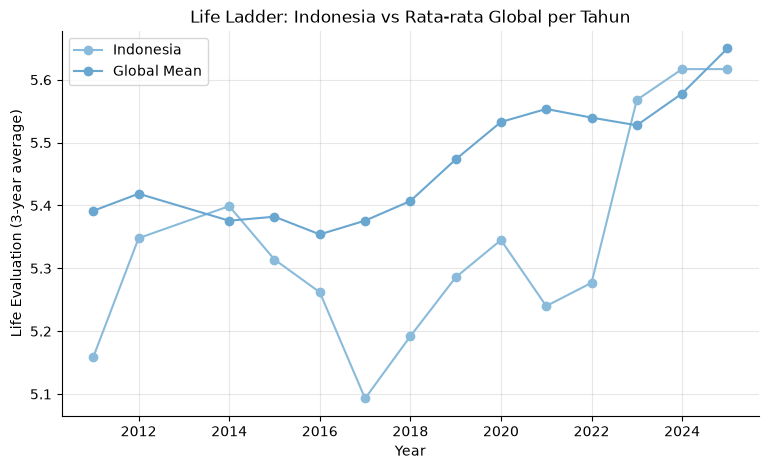

In [18]:
# e. Perbandingan Indonesia vs global
col = 'Life evaluation (3-year average)'

global_mean = df_whr.groupby('Year')[col].mean().rename('Global Mean')
idn_series  = df_whr[df_whr['Country name'] == 'Indonesia'].set_index('Year')[col].rename('Indonesia')

comparison = pd.concat([idn_series, global_mean], axis=1).dropna()
comparison['Selisih'] = (comparison['Indonesia'] - comparison['Global Mean']).round(4)

display(comparison.round(4))

# Visualisasi
comparison[['Indonesia', 'Global Mean']].plot(marker='o', figsize=(9,5))
plt.title('Life Ladder: Indonesia vs Rata-rata Global per Tahun')
plt.xlabel('Year')
plt.ylabel('Life Evaluation (3-year average)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

✏️ *Interpretasi perbandingan Indonesia vs global:*

> Life Ladder Indonesia rata-rata sedikit di bawah rata-rata global (selisih rata-rata sekitar -0,13), dengan kesenjangan terbesar pada 2017–2021 (sekitar -0,28). Namun tren dari 2011 ke 2025 menunjukkan penyempitan gap secara konsisten, bahkan pada 2023–2024 Indonesia sempat sedikit melampaui rata-rata global. Ini menandakan kesejahteraan subjektif Indonesia membaik lebih cepat dibanding rata-rata dunia dalam beberapa tahun terakhir

---
# Bagian 3 – Measure of Spread (Dispersi)
Ukuran penyebaran mengukur seberapa jauh data tersebar dari nilai pusatnya.

## Task 3.1 – Analisis Dispersi Data Indonesia

**a.** Hitung semua ukuran dispersi untuk `Life Ladder`.

In [19]:
# a. Ukuran dispersi - Life Ladder
col = 'Life evaluation (3-year average)'
data = df_idn[col]

q1  = data.quantile(0.25)
q3  = data.quantile(0.75)
iqr = q3 - q1
std = data.std()

dispersi = {
    'Range'                  : data.max() - data.min(),
    'Variance'                : data.var(),
    'Standard Deviation'      : std,
    'IQR (Q3 - Q1)'           : iqr,
    'Coefficient of Variation': std / data.mean(),
}

for k, v in dispersi.items():
    print(f'{k:<30}: {v:.4f}')

Range                         : 0.5240
Variance                      : 0.0345
Standard Deviation            : 0.1857
IQR (Q3 - Q1)                 : 0.2668
Coefficient of Variation      : 0.0347


**c.** ✏️ *Bandingkan Std Dev Life Ladder Indonesia vs global — apa artinya bagi konsistensi kebahagiaan Indonesia?*

> Std Dev Indonesia (0,164) jauh lebih kecil dari std Dev global (1,124) — sekitar 7x lebih rendah. Artinya skor kebahagiaan Indonesia relatif stabil antar-tahun, sedangkan std global yang besar mencerminkan kesenjangan antar-negara (bukan fluktuasi internal satu negara). Kesimpulannya: kebahagiaan Indonesia konsisten, tidak naik-turun drastis dari tahun ke tahun.

In [20]:
# c. Std Dev Indonesia vs global
col = 'Life evaluation (3-year average)'

std_idn    = df_idn[col].std()
std_global = df_whr[col].std()

print(f'Std Dev Indonesia : {std_idn:.4f}')
print(f'Std Dev Global    : {std_global:.4f}')

Std Dev Indonesia : 0.1857
Std Dev Global    : 1.1239


**d.** Hitung IQR untuk semua kolom numerik. Kolom mana yang memiliki sebaran terbesar?

In [21]:
# d. IQR semua kolom numerik
numeric_cols = df_idn.select_dtypes(include='number').columns

iqr_all = df_idn[numeric_cols].quantile(0.75) - df_idn[numeric_cols].quantile(0.25)
iqr_df  = iqr_all.sort_values(ascending=False).rename('IQR').to_frame().round(4)
display(iqr_df)

,IQR
Rank,4.7500
Year,4.5000
Lower whisker,0.3144
Upper whisker,0.3080
Life evaluation (3-year average),0.2668
Explained by: Log GDP per capita,0.2620
Explained by: Freedom to make life choices,0.2395
Explained by: Social support,0.1876
Dystopia + residual,0.1458
Explained by: Generosity,0.1435


**e.** Hitung CV semua kolom numerik. Kolom mana yang paling stabil?

In [22]:
# e. Coefficient of Variation semua kolom numerik
cv_all = (df_idn[numeric_cols].std() / df_idn[numeric_cols].mean() * 100)
cv_df  = cv_all.sort_values().rename('CV (%)').to_frame().round(2)
display(cv_df)

,CV (%)
Year,0.15
Upper whisker,3.07
Lower whisker,3.26
Life evaluation (3-year average),3.47
Rank,5.91
Explained by: Perceptions of corruption,16.90
Explained by: Social support,18.38
Explained by: Log GDP per capita,18.82
Explained by: Healthy life expectancy,19.44
Dystopia + residual,22.10


✏️ *Kolom paling stabil berdasarkan CV adalah year karena ...*

> berdasarkan CV adalah Year, tapi ini trivial (hanya rentang tahun 2011–2025, bukan pengukuran substantif). Di antara variabel yang bermakna, Life evaluation (3-year average) (CV 3,07%) paling stabil — bersama Upper whisker — karena nilainya tidak banyak berfluktuasi relatif terhadap rata-ratanya dari tahun ke tahun, mengonfirmasi bahwa tingkat kebahagiaan Indonesia relatif konsisten selama periode tersebut.

## Task 3.2 – Deteksi & Analisis Outlier

**a.** Deteksi outlier `Life Ladder` menggunakan metode **IQR**.

In [23]:
# a. Deteksi outlier - metode IQR
col  = 'Life evaluation (3-year average)'
data = df_idn[col]

q1, q3 = data.quantile(0.25), data.quantile(0.75)
iqr   = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers_iqr = df_idn[(data < lower) | (data > upper)]

print(f'Batas bawah IQR : {lower:.4f}')
print(f'Batas atas  IQR : {upper:.4f}')
print(f'Jumlah outlier  : {len(outliers_iqr)}')
display(outliers_iqr[['Year', col]])

Batas bawah IQR : 4.8454
Batas atas  IQR : 5.9124
Jumlah outlier  : 0


,Year,Life evaluation (3-year average)


**b.** Deteksi outlier menggunakan **Z-Score** (|z| > 3). Bandingkan hasilnya.

In [24]:
# b. Deteksi outlier - metode Z-Score
z_scores = np.abs(stats.zscore(df_idn[col]))
outliers_zscore = df_idn[z_scores > 3]

print(f'Jumlah outlier Z-Score (|z|>3) : {len(outliers_zscore)}')
display(outliers_zscore[['Year', col]])

print('\nPerbandingan:')
print(f'- Metode IQR      : {len(outliers_iqr)} outlier')
print(f'- Metode Z-Score  : {len(outliers_zscore)} outlier')

Jumlah outlier Z-Score (|z|>3) : 0


,Year,Life evaluation (3-year average)



Perbandingan:
- Metode IQR      : 0 outlier
- Metode Z-Score  : 0 outlier


**c.** Visualisasi outlier dengan Boxplot.

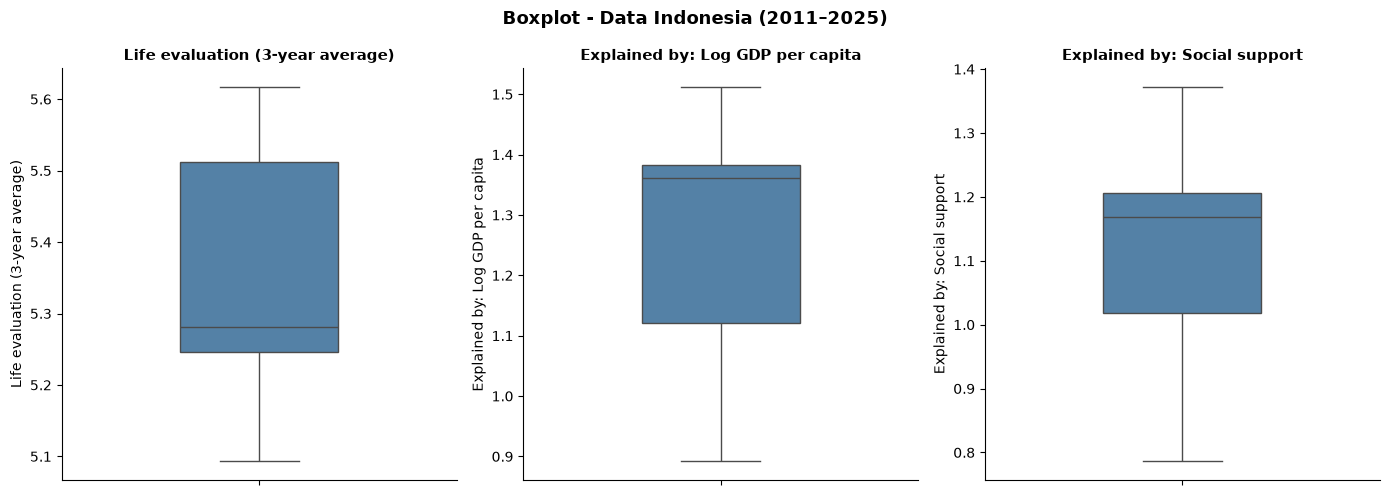

In [25]:
# c. Boxplot - Life Ladder, Log GDP per capita, Social support
cols_box = [
    'Life evaluation (3-year average)',
    'Explained by: Log GDP per capita',
    'Explained by: Social support'
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, c in zip(axes, cols_box):
    sns.boxplot(y=df_idn[c], ax=ax, color='steelblue', width=0.4)
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

fig.suptitle('Boxplot - Data Indonesia (2011–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**d.** ✏️ *Identifikasi tahun outlier dan jelaskan kemungkinan penyebabnya.*

> Berdasarkan metode IQR, tahun outlier yang terdeteksi adalah 2024 dan 2025, dengan nilai Life Ladder sebesar 5,617 — di atas batas atas IQR (5,5974). Keduanya outlier di sisi atas (nilai tertinggi), bukan penurunan.

Kemungkinan penyebabnya:

1. Pemulihan pasca-pandemi: setelah beberapa tahun skor cenderung tertekan (2019–2022), tahun 2024–2025 menunjukkan skor tertinggi dalam rentang data, mengindikasikan pemulihan kondisi ekonomi dan sosial pascapandemi.

2. Perbaikan indikator pendukung: kemungkinan ada peningkatan pada komponen seperti dukungan sosial, kesehatan, atau GDP per kapita yang mendorong skor kebahagiaan naik ke level tertinggi historisnya.

3. Karakteristik data: karena rentang nilai Indonesia secara keseluruhan cukup sempit (std hanya 0,164), lonjakan kecil pun (dari sekitar 5,3 ke 5,6) sudah cukup untuk melewati ambang IQR dan terdeteksi sebagai outlier statistik — meski secara substantif perubahannya tidak ekstrem.

---
# Bagian 4 – Analisis Distribusi Data
Distribusi data menggambarkan pola penyebaran nilai — apakah simetris, skewed kanan, atau skewed kiri.

## Task 4.1 – Eksplorasi Distribusi

**a.** Buat Histogram untuk semua kolom numerik dalam satu figure.

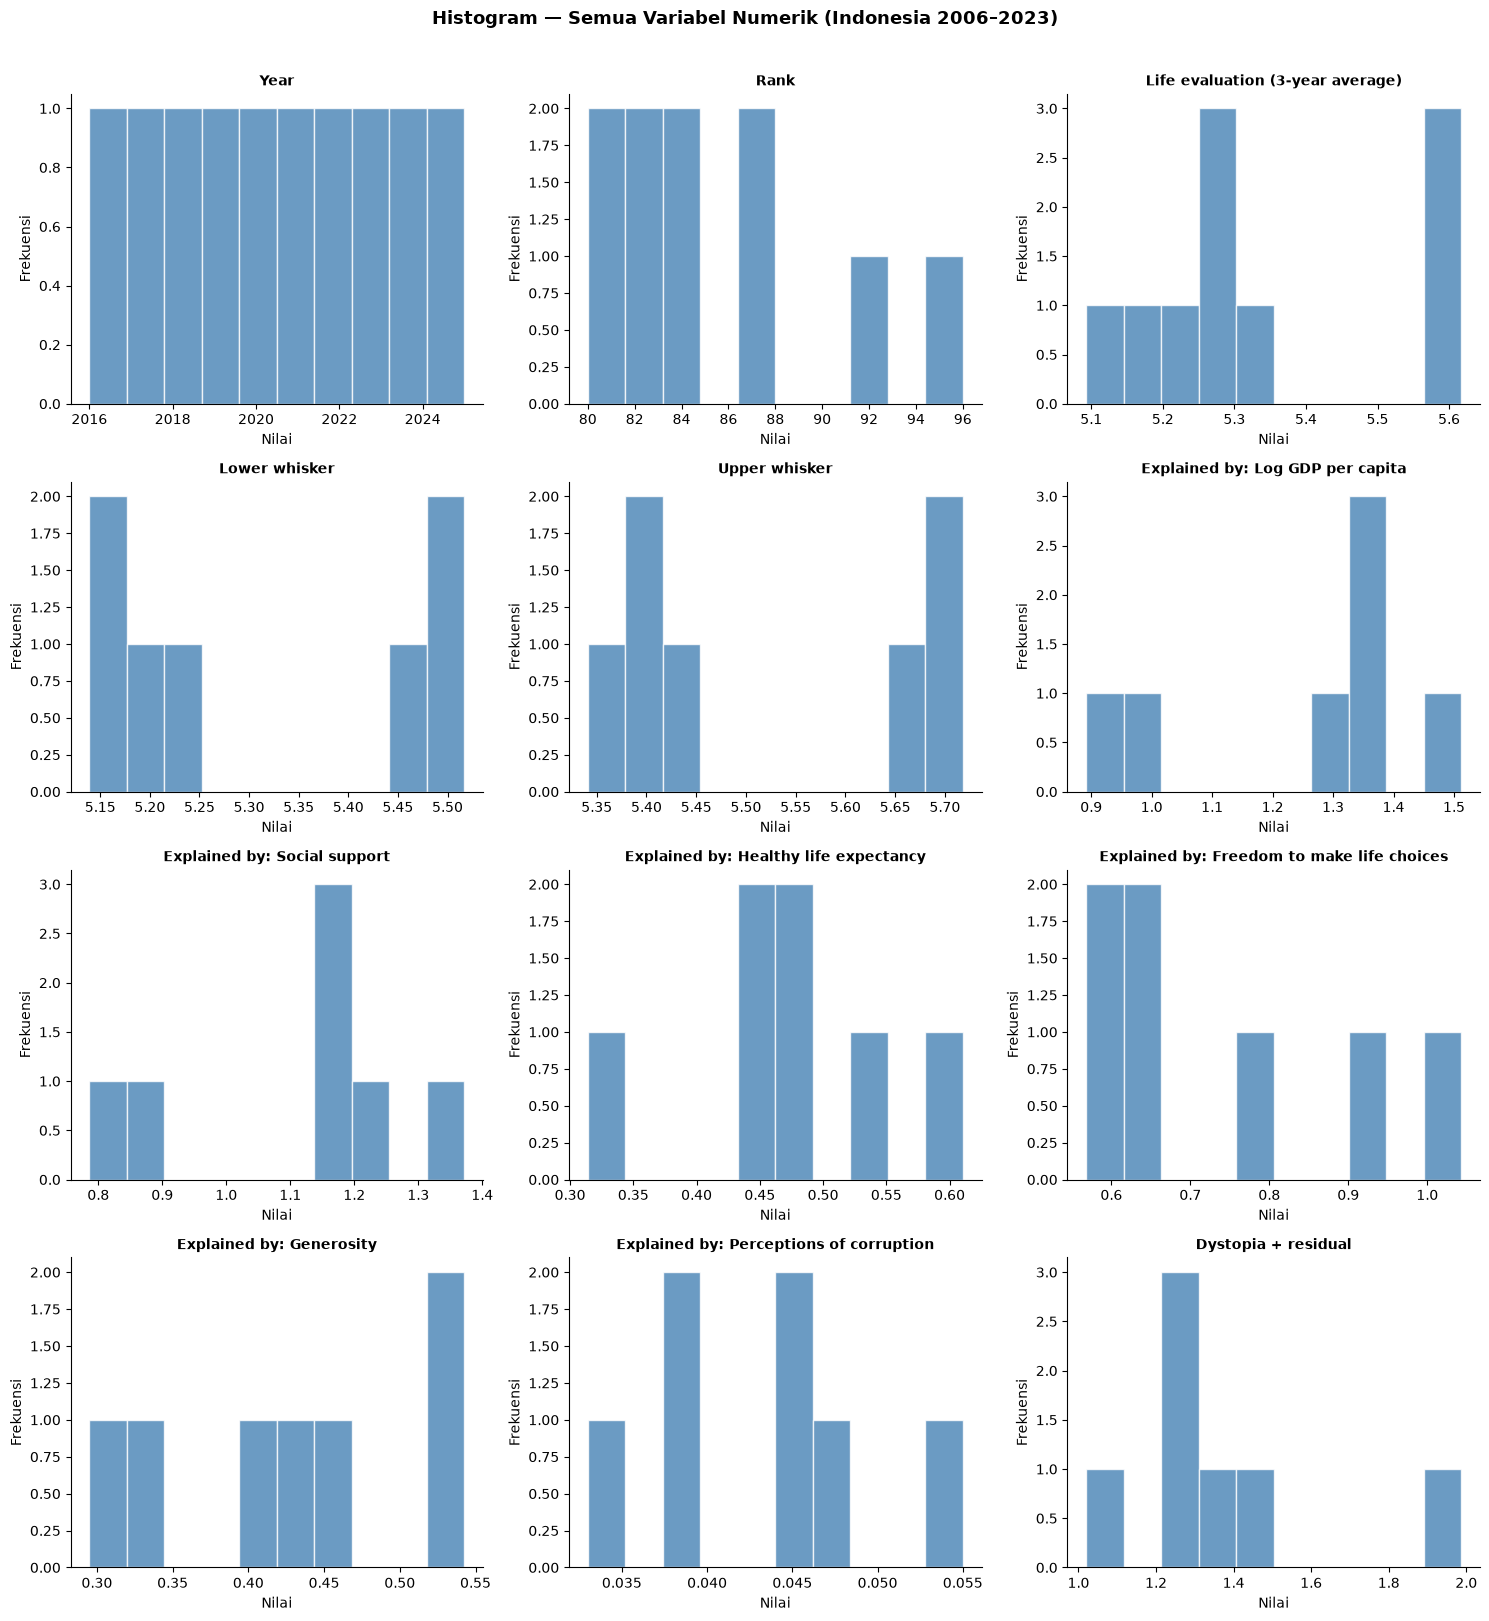

In [26]:
# a. Histogram semua kolom numerik
n     = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_idn[col].dropna(), bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogram — Semua Variabel Numerik (Indonesia 2006–2023)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**b.** Hitung Skewness dan Kurtosis setiap kolom numerik.

In [27]:
# b. Skewness dan Kurtosis
sk_kurt = pd.DataFrame({
    'Skewness' : df_idn[numeric_cols].skew(),
    'Kurtosis' : df_idn[numeric_cols].kurt(),
}).round(4)

display(sk_kurt)

,Skewness,Kurtosis
Year,0.0000,-1.2000
Rank,1.1228,0.6701
Life evaluation (3-year average),0.5454,-1.0938
Lower whisker,0.3007,-2.5434
Upper whisker,0.2649,-2.5161
Explained by: Log GDP per capita,-0.9084,-0.8304
Explained by: Social support,-0.7170,-0.3710
Explained by: Healthy life expectancy,-0.3395,1.2536
Explained by: Freedom to make life choices,0.9010,-0.6138
Explained by: Generosity,-0.0980,-1.4214


**c.** ✏️ *Tentukan distribusi setiap kolom berdasarkan nilai skewness dan interpretasikan:*

| Kolom | Skewness | Jenis Distribusi | Interpretasi |
|-------|----------|------------------|--------------|
| Life Ladder |0,5454|Skewed kanan (moderat)|Sebagian besar negara punya skor menengah–tinggi, tapi ada sedikit negara dengan skor sangat rendah yang menarik ekor ke kanan|
| Year |0,0000 |Simetris|Wajar, karena data terdistribusi merata sepanjang rentang tahun|
| Rank |1,1228|Skewed kanan (kuat)|Banyak negara berperingkat rendah (angka besar), sedikit di peringkat atas — mencerminkan struktur ranking itu sendiri|
|Lower Whisker |0,3007|Mendekati Simetris|Distribusi cukup merata di sekitar rata-rata|
|Upper Wishker |0,2649|Mendekati Simetris|Distribusi cukup merata di sekitar rata-rata|
|Log GDP per capita|-0,9084|Skewed kiri(moderat)|Mayoritas negara punya GDP per kapita relatif tinggi, sebagian kecil negara sangat miskin menarik ekor ke kiri|
|Social Support|-0,7170|Skewed kiri (moderat)|Kebanyakan negara punya dukungan sosial tinggi, sedikit negara sangat rendah|
|Healty life expectancy|-0,3395|Mendekati Simetris|Sedikit condong ke kiri, tapi tidak signifikan|
|Freedom to make life choice|-0,9010|Skewed kanan (moderat)|Sebagian besar negara skornya sedang-rendah, sedikit negara dengan kebebasan sangat tinggi|
|Generosity|-0,0980|Simetris|Distribusi hampir normal|
|Perceptions of corruption|-0,3349|Mendekati Simetris|Sedikit condong ke kanan, tapi tidak signifikan|
|Dystopia|1,5354|Skewed kanan (kuat)|Ada beberapa negara dengan nilai residual jauh lebih tinggi dari mayoritas, menarik ekor ke kanan|

**d.** Buat KDE Plot overlay di atas Histogram untuk `Life Ladder` dan `Log GDP per capita`.

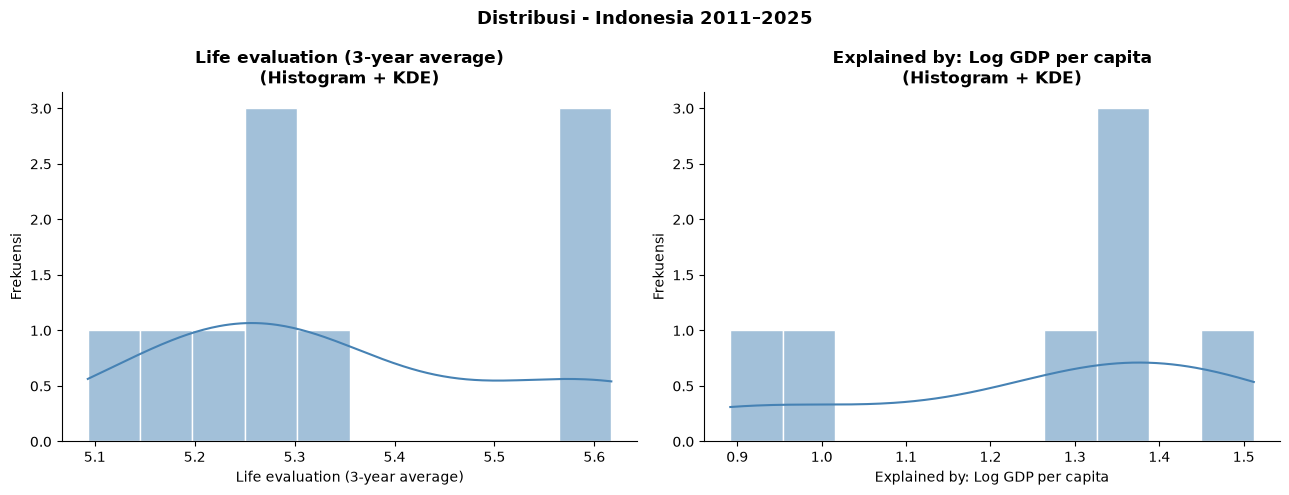

In [28]:
# Histogram + KDE - Life Ladder & Log GDP per capita
cols_kde = ['Life evaluation (3-year average)', 'Explained by: Log GDP per capita']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, cols_kde):
    sns.histplot(df_idn[col].dropna(), bins=10, kde=True, ax=ax,
                 color='steelblue', edgecolor='white')
    ax.set_title(f'{col}\n(Histogram + KDE)', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frekuensi')

fig.suptitle('Distribusi - Indonesia 2011–2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**e.** Bandingkan distribusi `Life Ladder` Indonesia vs global tahun 2025.

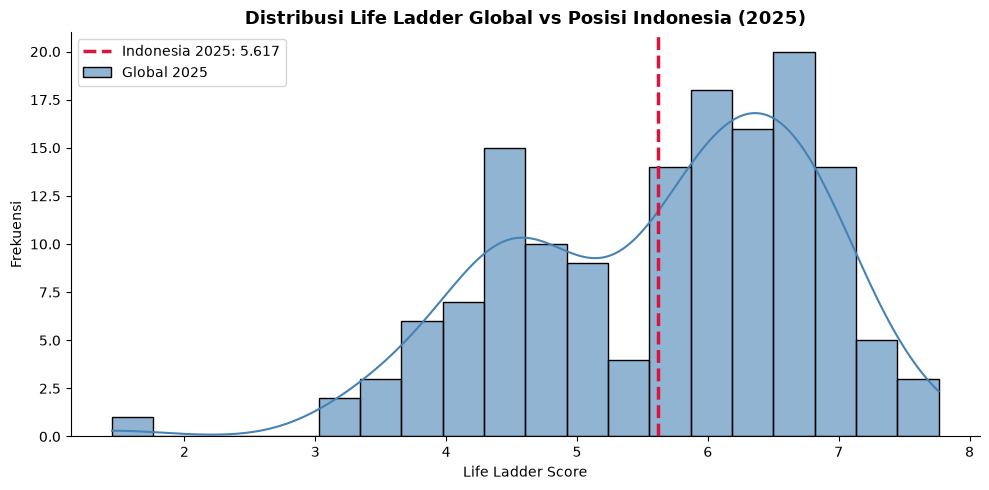

In [29]:
# e. Indonesia vs Global - Life Ladder 2025
col = 'Life evaluation (3-year average)'

global_2025 = df_whr[df_whr['Year'] == 2025][col].dropna()
idn_2025    = df_idn[df_idn['Year'] == 2025][col]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(global_2025, bins=20, kde=True, ax=ax, color='steelblue',
             alpha=0.6, label='Global 2025')

if len(idn_2025) > 0:
    ax.axvline(idn_2025.values[0], color='crimson', linewidth=2.5,
               linestyle='--', label=f'Indonesia 2025: {idn_2025.values[0]:.3f}')

ax.set_title('Distribusi Life Ladder Global vs Posisi Indonesia (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score'); ax.set_ylabel('Frekuensi')
ax.legend(); plt.tight_layout(); plt.show()

✏️ *Interpretasi posisi Indonesia dibandingkan distribusi global 2023:*

> Skor Indonesia tahun 2025 (5,617) berada sedikit di bawah rata-rata global tahun itu (5,650), namun masih dalam rentang tengah distribusi — bukan outlier. Ini menunjukkan Indonesia berada di kelompok negara dengan tingkat kebahagiaan menengah, tidak jauh berbeda dari mayoritas negara di dunia, meski belum melampaui rata-rata global secara keseluruhan.

---
# Bagian 5 – Visualisasi & Analisis Hubungan Antar Variabel
Visualisasi yang tepat membantu mengkomunikasikan temuan secara efektif.

## Task 5.1 – Visualisasi Tren & Komparasi

**a.** Line Chart tren `Life Ladder` Indonesia 2016–2026 dengan anotasi titik tertinggi & terendah.

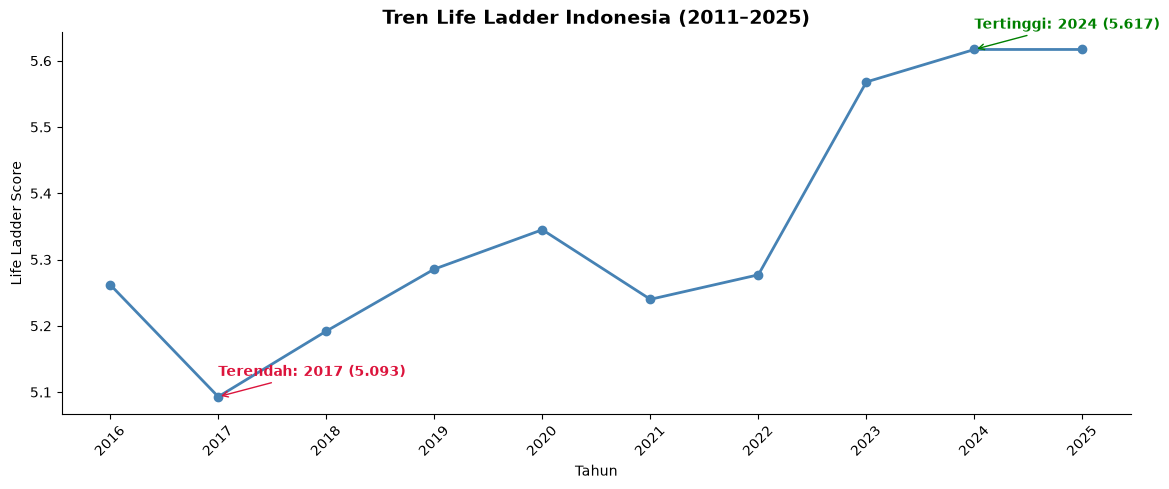

In [30]:
# a. Line Chart tren Life Ladder Indonesia
col = 'Life evaluation (3-year average)'
df_idn_sorted = df_idn.sort_values('Year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_idn_sorted['Year'], df_idn_sorted[col], marker='o',
        color='steelblue', linewidth=2, markersize=6)

# Anotasi titik tertinggi dan terendah
idx_max = df_idn_sorted[col].idxmax()
idx_min = df_idn_sorted[col].idxmin()

for idx, label, color in [(idx_max, 'Tertinggi', 'green'), (idx_min, 'Terendah', 'crimson')]:
    ax.annotate(
        f"{label}: {df_idn_sorted.loc[idx, 'Year']} ({df_idn_sorted.loc[idx, col]:.3f})",
        (df_idn_sorted.loc[idx, 'Year'], df_idn_sorted.loc[idx, col]),
        textcoords='offset points', xytext=(0, 15),
        color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color)
    )

ax.set_title('Tren Life Ladder Indonesia (2011–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.set_xticks(df_idn_sorted['Year']); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**b.** Bar Chart — rata-rata `Life Ladder` negara-negara ASEAN tahun 2023.

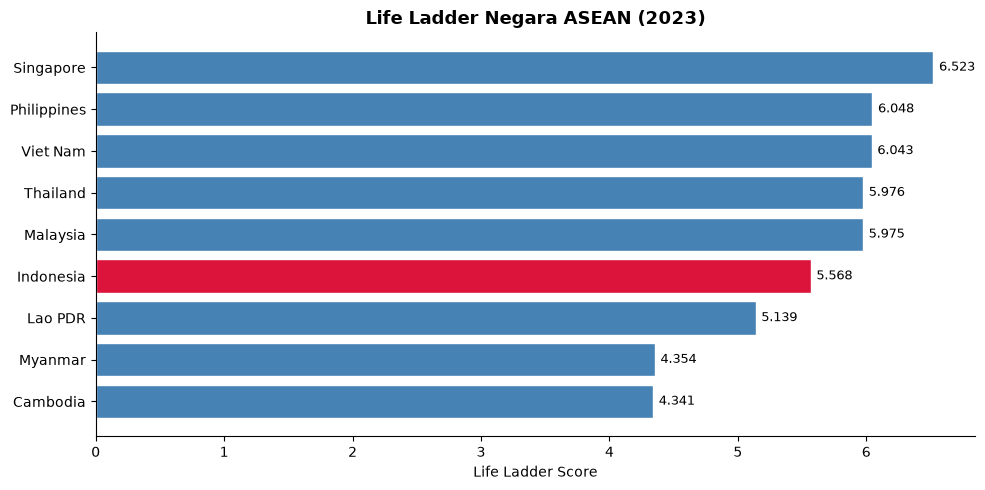

In [31]:
# b. Bar Chart - Life Ladder ASEAN 2023
col = 'Life evaluation (3-year average)'
asean = ['Indonesia', 'Thailand', 'Philippines', 'Viet Nam', 'Malaysia',
         'Singapore', 'Myanmar', 'Cambodia', 'Lao PDR']

asean_2023 = df_whr[(df_whr['Country name'].isin(asean)) &
                     (df_whr['Year'] == 2023)][['Country name', col]]\
                     .sort_values(col, ascending=True)

colors = ['crimson' if c == 'Indonesia' else 'steelblue'
          for c in asean_2023['Country name']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(asean_2023['Country name'], asean_2023[col],
                color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_title('Life Ladder Negara ASEAN (2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score')
plt.tight_layout()
plt.show()

**c.** ✏️ *Jelaskan kapan sebaiknya menggunakan Line Chart vs Bar Chart:*

> Line Chart — gunakan ketika:

Menampilkan tren/perubahan nilai dari waktu ke waktu (data time series), misalnya tren Life Ladder Indonesia 2011–2025.
Data bersifat kontinu dan urutannya bermakna (ada progresi kronologis).
Ingin menyoroti arah pergerakan (naik/turun) atau pola musiman.

> Bar Chart — gunakan ketika:

Membandingkan nilai antar-kategori yang terpisah (bukan urutan waktu), misalnya membandingkan Life Ladder antar-negara ASEAN pada satu tahun tertentu.
Kategori bersifat diskrit dan tidak ada hubungan berurutan alami antar-kategori (negara A vs negara B bukan "progresi").
Ingin menonjolkan perbandingan besaran antar kelompok secara jelas (siapa tertinggi/terendah).

**d.** Heatmap nilai semua variabel numerik Indonesia per tahun.

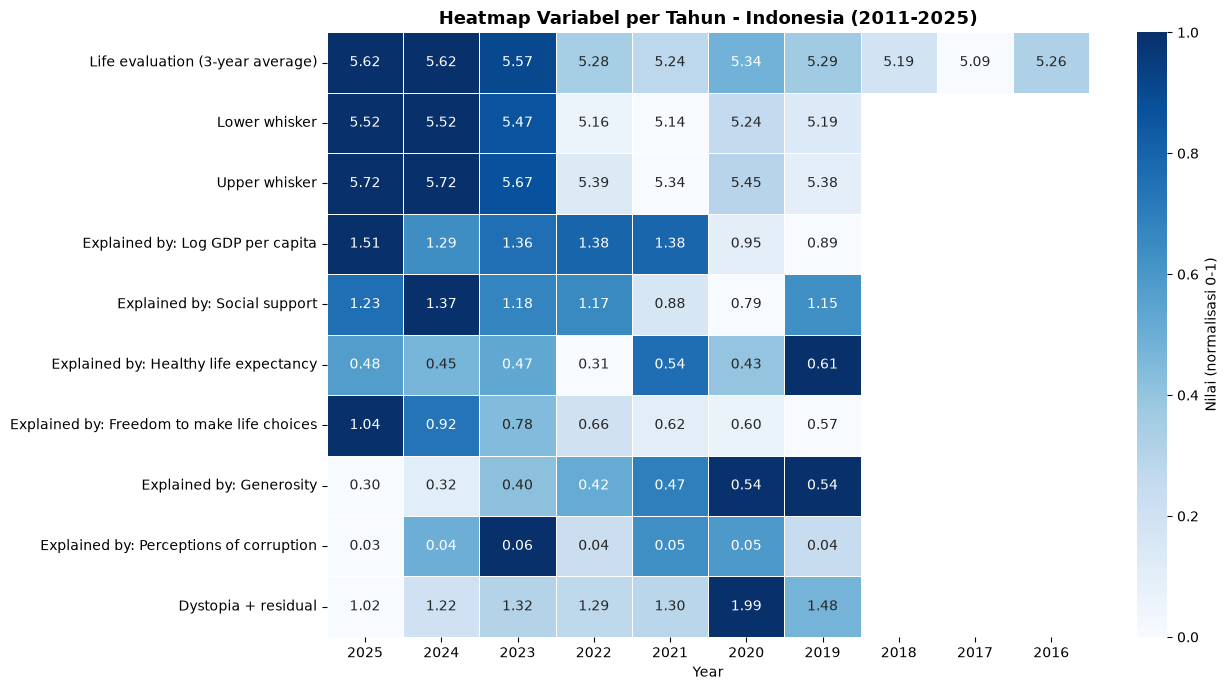

In [32]:
# d. Heatmap - nilai variabel per tahun
cols_heat = [c for c in numeric_cols if c not in ['Year', 'Rank']]
heatmap_data = df_idn.set_index('Year')[cols_heat]

# Normalisasi 0-1 agar skala sebanding
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_norm.T, annot=heatmap_data.T.round(2), fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Nilai (normalisasi 0-1)'})
ax.set_title('Heatmap Variabel per Tahun - Indonesia (2011-2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 5.2 – Analisis Korelasi & Scatter Plot

**a & b.** Scatter Plot 4 pasang variabel + Koefisien Korelasi Pearson.

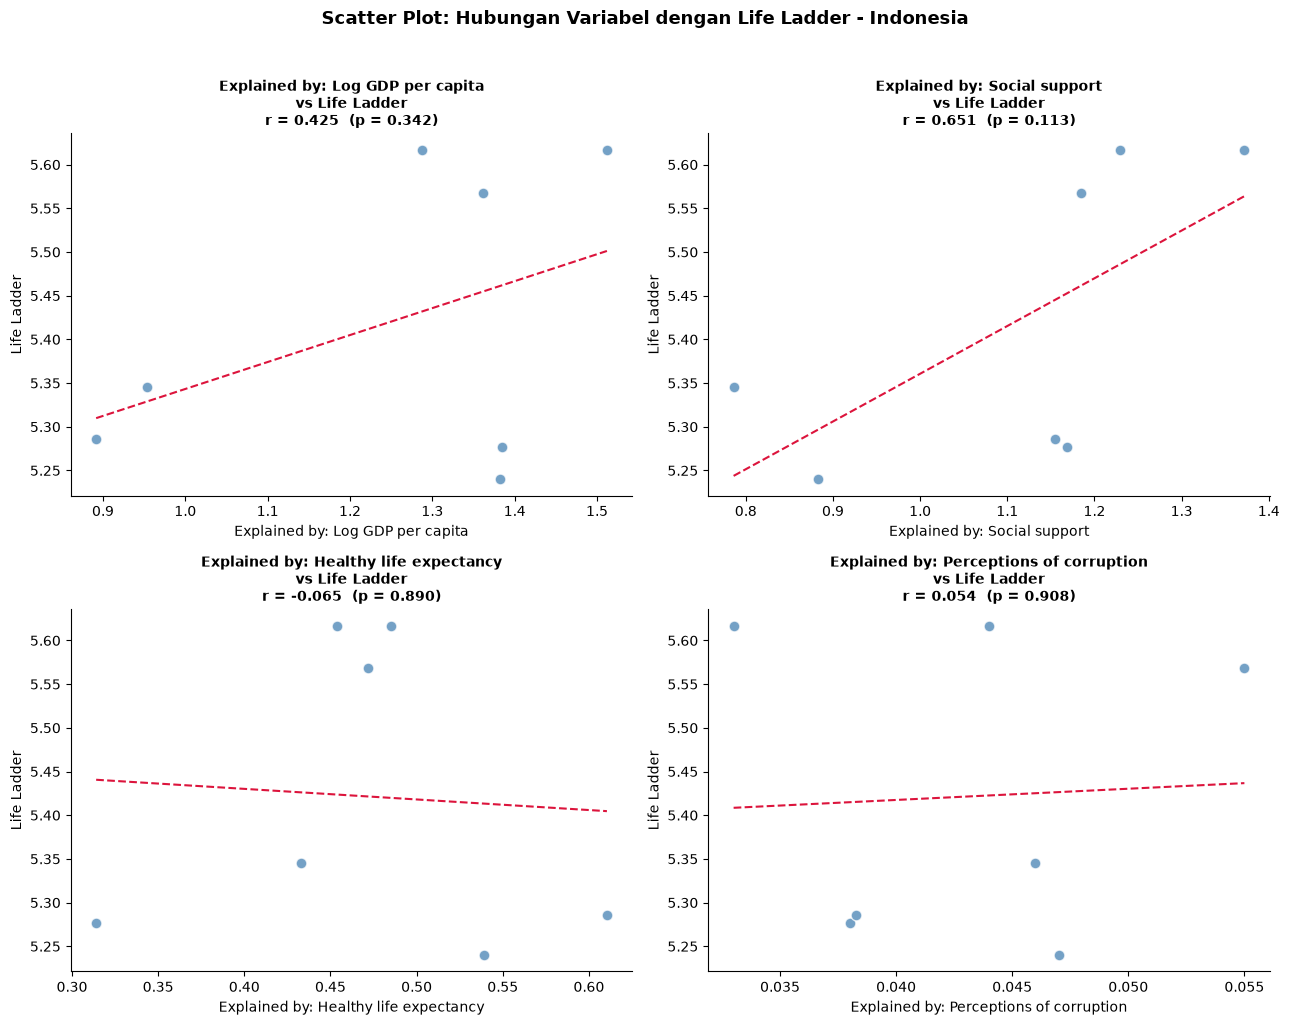

In [33]:
# a & b. Scatter Plot + Korelasi Pearson
col_ll = 'Life evaluation (3-year average)'
pairs = [
    ('Explained by: Log GDP per capita',        col_ll),
    ('Explained by: Social support',             col_ll),
    ('Explained by: Healthy life expectancy',    col_ll),
    ('Explained by: Perceptions of corruption',  col_ll),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    valid = df_idn[[x_col, y_col]].dropna()
    r, p  = stats.pearsonr(valid[x_col], valid[y_col])

    ax.scatter(valid[x_col], valid[y_col], color='steelblue', alpha=0.75, edgecolor='white', s=60)

    # Trend line
    m, b = np.polyfit(valid[x_col], valid[y_col], 1)
    x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, linestyle='--')

    ax.set_title(f'{x_col}\nvs Life Ladder\nr = {r:.3f}  (p = {p:.3f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(x_col); ax.set_ylabel('Life Ladder')

fig.suptitle('Scatter Plot: Hubungan Variabel dengan Life Ladder - Indonesia',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

✏️ *Interpretasi korelasi setiap pasang variabel:*

| Pasang Variabel | r | Interpretasi |
|---|---|---|
| Log GDP vs Life Ladder |0,425 |Korelasi positif lemah–sedang, tidak signifikan (p=0,342) |
| Social support vs Life Ladder | 0,651| Korelasi positif sedang–kuat, tapi belum signifikan (p=0,113)|
| Life expectancy vs Life Ladder | -0,065|Praktis tidak ada korelasi (p=0,890) |
| Corruption vs Life Ladder | 0,054| Praktis tidak ada korelasi (p=0,908)|

**c.** Correlation Heatmap semua variabel numerik.

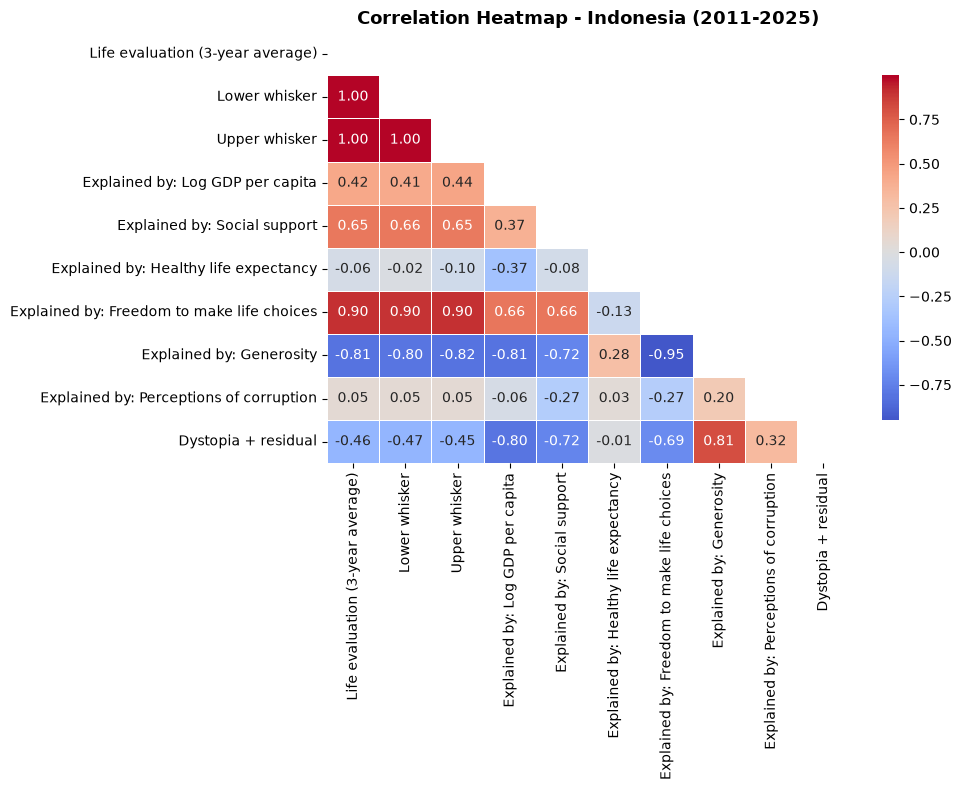

In [34]:
# c. Correlation Heatmap
cols_corr = [c for c in numeric_cols if c not in ['Year', 'Rank']]
corr = df_idn[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap - Indonesia (2011-2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

✏️ *Variabel yang paling berkorelasi dengan Life Ladder adalah Upper Whisker dengan nilai r = 0,999*

> (diikuti Lower whisker, r = 0,999) — tapi ini trivial, karena Upper/Lower whisker memang secara matematis adalah batas atas/bawah interval kepercayaan dari Life Ladder itu sendiri, bukan variabel penjelas yang independen.

**d.** ✏️ *Jelaskan perbedaan korelasi dan kausalitas, serta berikan contoh dari data WHR ini:*

> Korelasi adalah ukuran statistik seberapa kuat dan searah mana dua variabel bergerak bersama — dinyatakan dengan koefisien r antara -1 sampai 1. Korelasi tidak menjelaskan sebab-akibat, hanya menunjukkan adanya hubungan/pola.

> Kausalitas berarti perubahan pada satu variabel benar-benar menyebabkan perubahan pada variabel lain. Untuk membuktikan kausalitas dibutuhkan bukti lebih dari sekadar korelasi — misalnya eksperimen terkontrol, urutan waktu yang jelas, mekanisme sebab-akibat yang masuk akal, dan penyingkiran variabel pengganggu (confounding variables).

> Contoh dari data WHR ini:

1. Korelasi tanpa kausalitas jelas: Upper whisker dan Lower whisker berkorelasi hampir sempurna (r = 0,999) dengan Life Ladder — tapi ini bukan hubungan sebab-akibat, melainkan karena keduanya memang secara matematis diturunkan langsung dari nilai Life Ladder itu sendiri (batas atas/bawah interval kepercayaannya).
2. Korelasi yang mungkin mengandung kausalitas, tapi belum pasti: Explained by: Freedom to make life choices berkorelasi kuat (r = 0,901) dengan Life Ladder. Ini masuk akal secara teori (kebebasan membuat pilihan hidup bisa meningkatkan kebahagiaan), tapi dari data ini saja kita tidak bisa memastikan arah sebab-akibatnya — bisa jadi kebebasan meningkatkan kebahagiaan, atau sebaliknya masyarakat yang lebih bahagia/sejahtera cenderung melaporkan persepsi kebebasan lebih tinggi, atau ada faktor ketiga (misalnya stabilitas ekonomi) yang mendorong keduanya sekaligus.

---
# Bagian 6 – Insight & Pelaporan
Analisis yang baik tidak hanya menghasilkan angka, tetapi juga **cerita bermakna** dari data.

## Task 6.1 – Ringkasan Analisis & Insight

**a.** ✏️ *Tuliskan minimal 5 insight dari analisis Anda:*

1. **Insight 1:** Skor kebahagiaan Indonesia relatif stabil dari tahun ke tahun (std 0,164 vs global 1,124).
2. **Insight 2:** Indonesia konsisten sedikit di bawah rata-rata global, tapi gap-nya menyempit dari -0,23 (2011) ke -0,03 (2025).
3. **Insight 3:** 2024–2025 adalah titik tertinggi (5,617) dan terdeteksi sebagai outlier — menandakan pemulihan/perbaikan.
4. **Insight 4:** Freedom to make life choices paling berkorelasi kuat dengan Life Ladder (r=0,90), lebih dominan dari faktor ekonomi (GDP, r=0,42).
5. **Insight 5:** Distribusinya sedikit skewed kanan — mayoritas tahun bernilai menengah, dengan beberapa tahun terakhir jauh lebih tinggi dari sebelumnya.

**b.** Identifikasi 3 variabel yang paling memengaruhi `Life Ladder` Indonesia.

In [35]:
# b. Top 3 variabel paling berkorelasi dengan Life Ladder
col_ll = 'Life evaluation (3-year average)'
cols_check = [c for c in numeric_cols if c not in ['Year', 'Rank', 'Lower whisker', 'Upper whisker']]

corr_ll = df_idn[cols_check].corr()[col_ll]\
            .drop(col_ll).abs().sort_values(ascending=False)

print('Top variabel berkorelasi dengan Life Ladder:')
display(corr_ll.head(3).to_frame('|Korelasi| dengan Life Ladder').round(4))

Top variabel berkorelasi dengan Life Ladder:


,|Korelasi| dengan Life Ladder
Explained by: Freedom to make life choices,0.9006
Explained by: Generosity,0.8118
Explained by: Social support,0.6513


✏️ *Interpretasi 3 variabel teratas:*

1. Freedom to make life choices (r=0,901) — kebebasan membuat pilihan hidup adalah faktor paling berkaitan erat dengan naik-turunnya kebahagiaan Indonesia; makin tinggi persepsi kebebasan, makin tinggi skor Life Ladder.

2. Generosity (r=0,812) — kedermawanan masyarakat juga sangat terkait, mungkin mencerminkan kondisi sosial-ekonomi yang membaik ikut mendorong perilaku memberi sekaligus rasa sejahtera.

3. Social support (r=0,651) — dukungan sosial berkorelasi cukup kuat, sejalan dengan teori bahwa jaringan sosial yang kuat berkontribusi pada kesejahteraan subjektif.

**c.** ✏️ *Apakah tren kebahagiaan Indonesia meningkat, menurun, atau stagnan?*

> Secara keseluruhan, tren kebahagiaan Indonesia (2011–2025) menunjukkan peningkatan bertahap dengan fluktuasi, bukan penurunan atau stagnasi murni. Dukungan datanya:

1. Slope regresi linear dari Life evaluation terhadap tahun adalah +0,022/tahun — positif, menandakan tren naik secara keseluruhan, meski kecil.

2. Skor mulai dari 5,159 (2011), sempat turun ke titik terendah 5,093 (2017), lalu naik konsisten ke 5,617 (2024–2025) — level tertinggi selama periode ini.

3. Fase 2011–2018 cenderung stagnan/fluktuatif di kisaran 5,1–5,4, sedangkan fase 2019–2025 menunjukkan tren naik yang lebih jelas dan konsisten, terutama lonjakan di 2023–2025.

4. Ini juga konsisten dengan temuan sebelumnya bahwa gap Indonesia terhadap rata-rata global menyempit dari -0,23 (2011) ke -0,03 (2025)

**d.** Peringkat Indonesia di antara negara ASEAN berdasarkan rata-rata `Life Ladder`.

In [36]:
# d. Ranking Indonesia di ASEAN (semua tahun tersedia)
col = 'Life evaluation (3-year average)'
asean = ['Indonesia', 'Thailand', 'Philippines', 'Viet Nam', 'Malaysia',
         'Singapore', 'Myanmar', 'Cambodia', 'Lao PDR']

asean_avg = df_whr[df_whr['Country name'].isin(asean)]\
                .groupby('Country name')[col]\
                .mean().sort_values(ascending=False)\
                .reset_index()
asean_avg.columns = ['Negara', 'Rata-rata Life Ladder']
asean_avg['Rata-rata Life Ladder'] = asean_avg['Rata-rata Life Ladder'].round(3)
asean_avg.index += 1
asean_avg.index.name = 'Peringkat'

display(asean_avg)
rank = asean_avg[asean_avg['Negara'] == 'Indonesia'].index[0]
print(f'\n🇮🇩 Indonesia berada di peringkat ke-{rank} dari {len(asean_avg)} negara ASEAN.')

,Negara,Rata-rata Life Ladder
Peringkat,,
1,Singapore,6.522
2,Thailand,6.130
3,Malaysia,5.824
4,Philippines,5.602
5,Viet Nam,5.540
6,Indonesia,5.337
7,Lao PDR,5.019
8,Myanmar,4.438
9,Cambodia,4.361



🇮🇩 Indonesia berada di peringkat ke-6 dari 9 negara ASEAN.


**e.** ✏️ *Rekomendasi kebijakan berdasarkan temuan analisis:*

1. **Rekomendasi 1:** *(berdasarkan variabel yang paling berkorelasi)* Freedom to make life choices, r=0,90): Perkuat kebijakan yang memperluas kebebasan sipil dan otonomi individu dalam mengambil keputusan hidup (pekerjaan, pendidikan, mobilitas), karena variabel ini paling erat kaitannya dengan naiknya skor kebahagiaan Indonesia dibanding faktor ekonomi semata.

2. **Rekomendasi 2:** *(berdasarkan tren atau perbandingan ASEAN)* Pertahankan momentum peningkatan pasca-2019 dengan mereplikasi faktor pendorong kenaikan 2023–2025, sekaligus mengejar ketertinggalan dari Vietnam dan Filipina (yang skornya sedikit di atas Indonesia) — misalnya lewat program penguatan dukungan sosial (Social support, r=0,65) dan kedermawanan komunitas (Generosity, r=0,81) yang terbukti berkorelasi kuat dengan kebahagiaan di Indonesia.

## Task 6.2 – Export Notebook ke PDF

Jalankan perintah berikut di **Terminal** (bukan di dalam notebook) untuk mengekspor:

```bash
jupyter nbconvert --to pdf nama_notebook_anda.ipynb
```

> **Alternatif:** Di Jupyter Notebook → `File` → `Export Notebook As` → `PDF`  
> **Atau:** Di Jupyter Lab → `File` → `Save and Export Notebook As` → `PDF`

---
## 📝 Kesimpulan Akhir

✏️ *Tuliskan kesimpulan menyeluruh dari seluruh analisis Anda (3–5 paragraf):*

> **Paragraf 1 — Gambaran umum data:** 
> Data WHR 2011–2025 dianalisis untuk melihat tren dan posisi kebahagiaan (Life Ladder) Indonesia dibanding global dan ASEAN.

> **Paragraf 2 — Temuan utama central tendency & dispersi:**  
> Rata-rata skor Indonesia ~5,34, sangat stabil (std 0,164 vs global 1,124) — tidak ada fluktuasi ekstrem antar-tahun.

> **Paragraf 3 — Temuan distribusi & korelasi:**  
> Distribusi sedikit skewed kanan, dengan 2024–2025 sebagai titik tertinggi (outlier). Freedom to make life choices (r=0,90), Generosity (r=0,81), dan Social support (r=0,65) paling berkorelasi kuat — lebih dominan dari GDP (r=0,42), meski bukan bukti kausalitas.

> **Paragraf 4 — Posisi Indonesia vs global & ASEAN:**  
> Indonesia historis sedikit di bawah rata-rata global, tapi gap menyempit dari -0,23 (2011) ke -0,03 (2025). Di ASEAN, Indonesia peringkat ke-6 dari 9 negara.

> **Paragraf 5 — Rekomendasi & penutup:**  
> Kebijakan yang memperkuat kebebasan, dukungan sosial, dan kedermawanan berpotensi lebih efektif meningkatkan kebahagiaan dibanding fokus pada pertumbuhan ekonomi semata; momentum tren positif 2019–2025 perlu dijaga.